# 🧬 Notebook 7 — Genetic Risk Integration
## Population-PRS Calibration of Cardiovascular Risk Predictions
### CVD Digital Twin Project | CAD_DT_Final

---

## Purpose
This notebook integrates a population-level Polygenic Risk Score (PRS) with trained
ML models (lifestyle + clinical) to produce genetically-adjusted cardiovascular risk predictions.

## What this notebook does **NOT** do
- ❌ Retrain any model
- ❌ Modify any pipeline
- ❌ Use individual-level PRS — GenomeIndia only releases population-level allele frequencies publicly (individual genotypes require restricted government approval); this is an external data-governance constraint, not a design choice
- ❌ Claim a data-learned PRS weight — with only one PRS value shared by every patient, there is no within-sample variance to fit a regression coefficient on (see decisions below)

## Pipeline position
```
NB4 → prs_population_score.csv   (prs_raw, prs_mean_mc, CI)
NB5 → lifestyle_pipeline.pkl     (CalibratedClassifierCV)
NB6 → clinical_pipeline.pkl      (CalibratedClassifierCV)
NB7 → Genetically-adjusted risk  (THIS NOTEBOOK)
```

## I/O Contract
```
INPUTS:
  Outputs/Genetics/prs_population_score.csv
  Outputs/Models/lifestyle_pipeline.pkl
  Outputs/Models/clinical_pipeline.pkl
  Outputs/Lifestyle/df_lifestyle_test.csv
  Outputs/Clinical/df_clinical_test.csv

OUTPUTS:
  Outputs/Integrated/lifestyle_risk_scores_with_prs.csv
  Outputs/Integrated/clinical_risk_scores_with_prs.csv
  Outputs/Integrated/risk_stratification_bands.csv
  Outputs/Figures/risk_stratification_plot.png
  Outputs/Figures/calibration_curve_integrated.png
  Outputs/Figures/violin_plot_integrated.png
```

---

## Decisions adopted 2026-07-26 (after reviewing recent PRS-integration literature)
| # | Decision | Status |
|---|---|---|
| 1 | Z-score normalize PRS before sigmoid (`prs_z`, not raw `prs_raw`) | **Adopted** |
| 2 | Learn `w_prs` via nested-CV regression | **Rejected** — mathematically inapplicable to a constant, population-level PRS (zero within-sample variance) |
| 3 | Borrow a published log(HR) as the weight | **Not used directly** — PGS002809 has no published South Asian performance data; only a plausibility check against adjacent-literature effect sizes is honest here |
| 4 | Fixed, sensitivity-tested weight (w1=0.85 / w2=0.15) | **Adopted as the actual final method** — Section 4's sweep exists for transparency, not to pick the weight from test data |
| 5 | Report AUC + Brier + calibration for base vs. integrated | **Adopted** |
| 6 | Show "no-PRS" baseline alongside integrated results | **Adopted** |
| 7 | Formal NRI (not just raw reclassification counts) | **Adopted** — added to Section 5 |
| 8 | Decision-curve / net-benefit analysis | **Dropped** — out of scope for this pass |


> **Edit log — 2026-07-26:**
> - **Blocking bug fixed:** Section 4's code cell had bare, uncommented text (`maths model for compliance  - simulate`) — a hard `SyntaxError` that stopped "Run All" dead at Section 4, before risk stratification, evaluation, or any figure ever ran. Removed.
> - **PRS transform changed to Z-normalized** (`prs_z = (prs_raw - prs_mean_mc) / prs_sd_mc`, then `sigmoid(prs_z)`), replacing the raw `sigmoid(prs_raw)` that saturated at ≈0.999993 regardless of the actual PRS value. This resolves the notebook's own internal contradiction: Section 1's markdown argued for Z-normalization while Section 0/3 and the code argued against it — Z-normalization is the side actually consistent with standard PRS literature practice.
> - `prs_sd_mc` is read from the PRS CSV if present; if not, it's derived from the 95% CI half-width (`(ci_upper - ci_lower) / (2 × 1.95996)`) with this fallback printed explicitly so it's never silently assumed.
> - **Integration weight stays fixed (w1=0.85 / w2=0.15), not learned** — documented explicitly as a deliberate decision, not an oversight: a population-level PRS has no within-sample variance, so no regression coefficient can legitimately be fit on it. The Section 4 sensitivity sweep is kept for transparency/reporting, not used to select the weight from test data (which would itself be a leakage risk).
> - **Added formal NRI** (Net Reclassification Improvement, separate up/down movement for cases vs. controls) to Section 5/6, replacing the previous raw reclassification-count-only reporting.
> - Section 2's markdown no longer hardcodes both pipelines as `XGBClassifier` — the clinical pipeline is Logistic Regression as of NB6's 2026-07-25 fix; wording is now generic since the code never assumed a specific model type anyway.
> - Section 8: removed a duplicated `prs_sigmoid` print line, updated the NB8 usage hint to reflect the Z-normalized formula and both pipelines, and removed one empty trailing cell.


---
# Section 1 — Setup, Paths & Data Loading

## Why integrate PRS with model predictions?
ML models trained on lifestyle and clinical features capture **modifiable** and **measurable**
risk factors, but are blind to an individual's genetic predisposition. The Polygenic Risk Score
(PRS) from PGS Catalog (PGS002809), harmonised against GenomeIndia ancestry frequencies in NB3–4,
provides a **population-level genetic baseline** specific to Indian ancestry.

## Why sigmoid(prs_z) and not sigmoid(prs_raw)?
The raw PRS is a weighted sum over 182 SNPs: `prs_raw ≈ 11.88`. Passing this directly
into `sigmoid()` produces ≈ 0.9999 — saturated and scientifically meaningless as a weight.
The correct transformation is to first **Z-normalise** the PRS relative to the Monte Carlo
sampling distribution (mean and SD derived from the 10,000-simulation CI computed in NB4):

```
prs_z     = (prs_raw - prs_mean_mc) / prs_sd_mc
prs_sigmoid = sigmoid(prs_z)
```

By construction, a population-mean Indian-ancestry individual gives `prs_z ≈ 0` and
`sigmoid(0) = 0.50` — a neutral, centred genetic weight. Individuals with elevated PRS
would yield `prs_z > 0` → weight > 0.50; depleted PRS → weight < 0.50.

## Integration formula
```
p_integrated = w1 × p_model + w2 × prs_sigmoid
             = 0.85 × p_model + 0.15 × sigmoid(prs_z)
```
PRS contributes only 15% of the final score — it acts as a **calibration offset**,
not a dominant predictor.


In [1]:
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 88.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.9.0


In [3]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, roc_curve
)

# ── Mount Drive ───────────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('✅ Google Drive mounted')
except ImportError:
    print('ℹ️  Not in Colab — using local paths')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR = '/content/drive/MyDrive/CAD_DT_Final/'

PRS_PATH          = BASE_DIR + 'Outputs/Genetics/prs_population_score.csv'
LIFESTYLE_PKL     = BASE_DIR + 'Outputs/Models/lifestyle_pipeline.pkl'
CLINICAL_PKL      = BASE_DIR + 'Outputs/Models/clinical_pipeline.pkl'
LIFESTYLE_TEST    = BASE_DIR + 'Outputs/Lifestyle/df_lifestyle_test.csv'
CLINICAL_TEST     = BASE_DIR + 'Outputs/Clinical/df_clinical_test.csv'

INTEGRATED_DIR    = BASE_DIR + 'Outputs/Integrated/'
FIGURES_DIR       = BASE_DIR + 'Outputs/Figures/'

LS_OUT_PATH       = INTEGRATED_DIR + 'lifestyle_risk_scores_with_prs.csv'
CL_OUT_PATH       = INTEGRATED_DIR + 'clinical_risk_scores_with_prs.csv'
BANDS_OUT_PATH    = INTEGRATED_DIR + 'risk_stratification_bands.csv'
STRAT_FIG_OUT     = FIGURES_DIR    + 'risk_stratification_plot.png'
CALIB_FIG_OUT     = FIGURES_DIR    + 'calibration_curve_integrated.png'
VIOLIN_FIG_OUT    = FIGURES_DIR    + 'violin_plot_integrated.png'

os.makedirs(INTEGRATED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR,    exist_ok=True)

# ── Pre-flight check ──────────────────────────────────────────────────────────
print('\n' + '='*60)
print('  NB7 — GENETIC RISK INTEGRATION')
print('='*60)
for path, label in [
    (PRS_PATH,       'PRS CSV'),
    (LIFESTYLE_PKL,  'lifestyle_pipeline.pkl'),
    (CLINICAL_PKL,   'clinical_pipeline.pkl'),
    (LIFESTYLE_TEST, 'df_lifestyle_test.csv'),
    (CLINICAL_TEST,  'df_clinical_test.csv'),
]:
    exists = os.path.isfile(path)
    print(f"  {'✅' if exists else '❌'} {label}: {path}")
    if not exists:
        raise FileNotFoundError(f'Missing required file: {path}')

# ── Load PRS ──────────────────────────────────────────────────────────────────
prs_df = pd.read_csv(PRS_PATH)
assert 'prs_raw'     in prs_df.columns, '❌ prs_raw missing from PRS CSV'
assert 'prs_mean_mc' in prs_df.columns, '❌ prs_mean_mc missing from PRS CSV'
assert 'ci_lower'    in prs_df.columns, '❌ ci_lower missing from PRS CSV'
assert 'ci_upper'    in prs_df.columns, '❌ ci_upper missing from PRS CSV'

prs_raw     = float(prs_df['prs_raw'].values[0])
prs_mean_mc = float(prs_df['prs_mean_mc'].values[0])
ci_lower    = float(prs_df['ci_lower'].values[0])
ci_upper    = float(prs_df['ci_upper'].values[0])
n_snps      = int(prs_df['n_snps'].values[0])

# ── prs_sd_mc (added 2026-07-26, fixed 2026-07-27) ──────────────────────────
# Needed to Z-normalize prs_raw. NB4 (2026-07-24 edit) exports this as 'prs_std',
# not 'prs_sd_mc' — the original check here looked for the wrong column name
# and silently fell back to a CI-derived approximation every time, even though
# NB4 already computes the real Monte Carlo std directly. Fixed to check
# 'prs_std' first (verified against NB4's actual output: matches to 5 decimals),
# then 'prs_sd_mc' for forward-compatibility, then the CI-derived fallback last.
if 'prs_std' in prs_df.columns:
    prs_sd_mc = float(prs_df['prs_std'].values[0])
    sd_source = "from PRS CSV ('prs_std', NB4's real Monte Carlo std)"
elif 'prs_sd_mc' in prs_df.columns:
    prs_sd_mc = float(prs_df['prs_sd_mc'].values[0])
    sd_source = "from PRS CSV ('prs_sd_mc')"
else:
    prs_sd_mc = (ci_upper - ci_lower) / (2 * 1.959963984540054)
    sd_source = 'DERIVED from 95% CI half-width (neither prs_std nor prs_sd_mc found)'

# ── sigmoid_prs precomputed check (added 2026-07-27) ────────────────────────
# NB4 (2026-07-24 edit) also exports prs_z and sigmoid_prs directly, computed
# from the exact same Monte Carlo run. Section 3 below recomputes locally by
# default (keeps this notebook self-contained and auditable); this just records
# whether a precomputed value exists so Section 3 can cross-check against it.
prs_z_precomputed       = float(prs_df['prs_z'].values[0])       if 'prs_z' in prs_df.columns else None
sigmoid_prs_precomputed = float(prs_df['sigmoid_prs'].values[0]) if 'sigmoid_prs' in prs_df.columns else None

print(f'\n📊 PRS Summary:')
print(f'   prs_raw     = {prs_raw:.6f}')
print(f'   prs_mean_mc = {prs_mean_mc:.6f}')
print(f'   prs_sd_mc   = {prs_sd_mc:.6f}  ({sd_source})')
print(f'   95% CI      = [{ci_lower:.6f}, {ci_upper:.6f}]')
print(f'   n_snps      = {n_snps}')
if prs_z_precomputed is not None:
    print(f'   ℹ️  NB4 also precomputed: prs_z={prs_z_precomputed:.6f}, sigmoid_prs={sigmoid_prs_precomputed:.6f}')
if sd_source.startswith('DERIVED'):
    print(f'   ⚠️  prs_sd_mc derived, not loaded — verify against NB4 if precision matters')

# ── Load pipelines ────────────────────────────────────────────────────────────
with open(LIFESTYLE_PKL, 'rb') as f:
    lifestyle_pipeline = pickle.load(f)
with open(CLINICAL_PKL, 'rb') as f:
    clinical_pipeline = pickle.load(f)

print(f'\n✅ Pipelines loaded:')
print(f'   lifestyle_pipeline : {type(lifestyle_pipeline).__name__}')
print(f'   clinical_pipeline  : {type(clinical_pipeline).__name__}')

# ── Load test datasets ────────────────────────────────────────────────────────
df_lifestyle = pd.read_csv(LIFESTYLE_TEST)
df_clinical  = pd.read_csv(CLINICAL_TEST)

print(f'\n📊 Test datasets:')
print(f'   Lifestyle test : {df_lifestyle.shape}')
print(f'   Clinical test  : {df_clinical.shape}')

print('\n[SECTION 1 COMPLETE] ✅')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted

  NB7 — GENETIC RISK INTEGRATION
  ✅ PRS CSV: /content/drive/MyDrive/CAD_DT_Final/Outputs/Genetics/prs_population_score.csv
  ✅ lifestyle_pipeline.pkl: /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/lifestyle_pipeline.pkl
  ✅ clinical_pipeline.pkl: /content/drive/MyDrive/CAD_DT_Final/Outputs/Models/clinical_pipeline.pkl
  ✅ df_lifestyle_test.csv: /content/drive/MyDrive/CAD_DT_Final/Outputs/Lifestyle/df_lifestyle_test.csv
  ✅ df_clinical_test.csv: /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_test.csv

📊 PRS Summary:
   prs_raw     = 11.881286
   prs_mean_mc = 11.881228
   prs_sd_mc   = 0.006453  (from PRS CSV ('prs_std', NB4's real Monte Carlo std))
   95% CI      = [11.868590, 11.893911]
   n_snps      = 182
   ℹ️  NB4 also precomputed: prs_z=0.009032, sigmoid_prs=0.502258

✅ Pipelines loaded:
   lifestyle_pipel

---
# Section 2 — Generate Base Model Predictions

## What the models produce
Both pipelines are `CalibratedClassifierCV(Pipeline([StandardScaler, <classifier>]))` — the inner classifier differs per pipeline (whichever model NB5/NB6 selected; as of NB6's 2026-07-25 gap-aware selection fix, the clinical pipeline is Logistic Regression, not a tree ensemble). This notebook never assumes a specific model type — `predict_proba` is generic sklearn API.
Calling `pipeline.predict_proba(X)[:, 1]` returns a **calibrated probability**
that the patient has or will develop cardiovascular disease.

These probabilities reflect the model's view of risk based purely on lifestyle or
clinical measurements — with **no genetic component** yet.

## Feature selection
Each pipeline was trained on a specific feature subset (determined by NB5/NB6).
We pass only the features the pipeline expects, derived directly from its fitted scaler.


In [4]:
print('='*60)
print('  SECTION 2: Base Model Predictions')
print('='*60)

TARGET_COL = 'target'

# ── Extract expected feature names from fitted scaler inside pipeline ─────────
def get_pipeline_features(pipeline):
    """Return the feature names the pipeline was trained on."""
    inner_pipe = pipeline.calibrated_classifiers_[0].estimator
    scaler = inner_pipe.named_steps['scaler']
    if hasattr(scaler, 'feature_names_in_'):
        return scaler.feature_names_in_.tolist()
    raise ValueError('Scaler has no feature_names_in_. Re-fit pipeline with DataFrame input.')

LS_FEATURES = get_pipeline_features(lifestyle_pipeline)
CL_FEATURES = get_pipeline_features(clinical_pipeline)

print(f'\n  Lifestyle features ({len(LS_FEATURES)}): {LS_FEATURES}')
print(f'  Clinical features  ({len(CL_FEATURES)}): {CL_FEATURES}')

# ── Separate features / target ────────────────────────────────────────────────
assert TARGET_COL in df_lifestyle.columns, f'❌ {TARGET_COL} missing from lifestyle test'
assert TARGET_COL in df_clinical.columns,  f'❌ {TARGET_COL} missing from clinical test'

X_ls = df_lifestyle[LS_FEATURES]
y_ls = df_lifestyle[TARGET_COL]

X_cl = df_clinical[CL_FEATURES]
y_cl = df_clinical[TARGET_COL]

assert list(X_ls.columns) == LS_FEATURES, '❌ Column mismatch for lifestyle'
assert list(X_cl.columns) == CL_FEATURES, '❌ Column mismatch for clinical'
print('\n  ✅ Feature column alignment confirmed')

# ── Generate base probabilities ───────────────────────────────────────────────
p_lifestyle_base = lifestyle_pipeline.predict_proba(X_ls)[:, 1]
p_clinical_base  = clinical_pipeline.predict_proba(X_cl)[:, 1]

print(f'\n📊 Base Model Probabilities:')
print(f'   Lifestyle  — n={len(p_lifestyle_base):,}  '
      f'mean={p_lifestyle_base.mean():.4f}  '
      f'range=[{p_lifestyle_base.min():.4f}, {p_lifestyle_base.max():.4f}]')
print(f'   Clinical   — n={len(p_clinical_base):,}   '
      f'mean={p_clinical_base.mean():.4f}  '
      f'range=[{p_clinical_base.min():.4f}, {p_clinical_base.max():.4f}]')

auc_ls_base   = roc_auc_score(y_ls, p_lifestyle_base)
brier_ls_base = brier_score_loss(y_ls, p_lifestyle_base)
auc_cl_base   = roc_auc_score(y_cl, p_clinical_base)
brier_cl_base = brier_score_loss(y_cl, p_clinical_base)

print(f'\n  Base AUC / Brier (before PRS integration):')
print(f'   Lifestyle  AUC={auc_ls_base:.4f}  Brier={brier_ls_base:.4f}')
print(f'   Clinical   AUC={auc_cl_base:.4f}  Brier={brier_cl_base:.4f}')

print('\n[SECTION 2 COMPLETE] ✅')


  SECTION 2: Base Model Predictions

  Lifestyle features (14): ['age', 'gender', 'systolic_bp', 'diastolic_bp', 'smoking', 'alcohol', 'physical_activity', 'bmi', 'cholesterol_level_1', 'cholesterol_level_2', 'cholesterol_level_3', 'glucose_level_1', 'glucose_level_2', 'glucose_level_3']
  Clinical features  (10): ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'oldpeak', 'resting_ecg_0.0', 'resting_ecg_1.0', 'resting_ecg_2.0']

  ✅ Feature column alignment confirmed

📊 Base Model Probabilities:
   Lifestyle  — n=13,715  mean=0.4942  range=[0.0911, 0.8991]
   Clinical   — n=184   mean=0.5583  range=[0.0314, 0.9832]

  Base AUC / Brier (before PRS integration):
   Lifestyle  AUC=0.7971  Brier=0.1824
   Clinical   AUC=0.8935  Brier=0.1338

[SECTION 2 COMPLETE] ✅


# Section 3 — PRS Transformation & Integration

## Why we Z-normalize PRS (decision, 2026-07-26)

The population-level PRS (`prs_raw ≈ 11.88`) is a weighted sum of log(OR) terms over **182 variants** — confirmed via NB3's actual executed harmonization run (2026-07-27): PGS002809 starts at 205 SNPs (matches the PGS Catalog record exactly); 189 remain after coordinate + allele harmonization against GenomeIndia (16 dropped: no positional match); 186 after the palindromic-SNP filter (3 dropped: strand-ambiguous in the 0.42–0.58 frequency zone); 182 after the MAF filter (4 dropped: risk-allele frequency <1% in Indian ancestry). Every dropped SNP is individually logged with its rsID in NB3's `dropped_snps_audit_log.csv`. Passing this directly into `sigmoid()`:

    sigmoid(prs_raw) ≈ 0.999993

saturates almost completely. The practical consequence: any `prs_raw` above roughly 5 would land at essentially the same ≈1.0 — meaning the specific number the entire GenomeIndia-calibrated, Monte-Carlo-validated PRS pipeline computes barely affects the final output at all. That's a legitimate weakness to have flagged before a reviewer does.

**Decision:** Z-normalize before the sigmoid, as is standard practice in the PRS literature (scores are conventionally reported and used per-SD):

    prs_z       = (prs_raw - prs_mean_mc) / prs_sd_mc
    prs_sigmoid = sigmoid(prs_z)

By construction, a population-mean Indian-ancestry individual gives `prs_z ≈ 0` and `sigmoid(0) = 0.50` — a neutral, centered genetic weight, not a saturated one.

## What this does and doesn't fix
This is still a **population-level, single-value offset** — the same `prs_sigmoid` is added to every patient, because that's the only PRS we have (see header: individual GenomeIndia genotypes aren't publicly accessible). Z-normalizing changes *how large* that constant shift is (≈0.075 vs. ≈0.15), and makes the number scientifically interpretable, but it does not — and cannot — make the PRS discriminate between patients. AUC is expected to be unchanged either way; this is a calibration correction, not a discrimination improvement. That expectation is checked explicitly in Section 6.

## Integration formula

    p_integrated = w1 × p_model + w2 × sigmoid(prs_z)
                 = 0.85 × p_model + 0.15 × sigmoid(prs_z)

**The weight (w1/w2) is fixed and sensitivity-tested (Section 4), not learned from data** — with a single shared PRS value across all patients, there's no within-sample variance to fit a regression coefficient on. This is a deliberate, documented decision, not a missing step.


In [5]:
print('='*60)
print('  SECTION 3: PRS Integration (Population-Level Offset)')
print('='*60)

# ── PRS transformation (Z-normalized, decision 2026-07-26) ────────
# See Section 3 markdown for why: raw sigmoid(prs_raw) saturates at ~0.999993
# regardless of the actual PRS value, making the offset uninformative.

prs_z       = (prs_raw - prs_mean_mc) / prs_sd_mc
prs_sigmoid = float(1.0 / (1.0 + np.exp(-prs_z)))

print(f'\n  PRS Transformation:')
print(f'   prs_raw     = {prs_raw:.6f}')
print(f'   prs_mean_mc = {prs_mean_mc:.6f}')
print(f'   prs_sd_mc   = {prs_sd_mc:.6f}')
print(f'   prs_z       = {prs_z:+.6f}')
print(f'   prs_sigmoid = {prs_sigmoid:.6f}')

if abs(prs_z) < 0.1:
    print('   ℹ️  prs_z ≈ 0 — this population sits near the center of its own Monte Carlo')
    print('      reference distribution (expected: prs_raw and prs_mean_mc are both derived')
    print('      from the same GenomeIndia allele frequencies)')
elif prs_sigmoid > 0.95 or prs_sigmoid < 0.05:
    print('   ⚠️  prs_sigmoid still near-saturated even after Z-normalization —')
    print('      check prs_sd_mc is correct before trusting this offset.')

# ── Cross-check against NB4's precomputed value (added 2026-07-27) ──────
# NB4 (2026-07-24 edit) computes this exact same prs_z/sigmoid_prs itself and
# exports it. Recomputing locally (above) keeps this notebook self-contained
# and auditable; this check just confirms the two independent computations
# agree, catching a silent mismatch (e.g. stale PRS CSV) rather than assuming.
if sigmoid_prs_precomputed is not None:
    diff = abs(prs_sigmoid - sigmoid_prs_precomputed)
    if diff < 1e-4:
        print(f'\n   ✅ Cross-check vs NB4 precomputed sigmoid_prs={sigmoid_prs_precomputed:.6f}: '
              f'matches (diff={diff:.2e})')
    else:
        print(f'\n   ⚠️  Cross-check vs NB4 precomputed sigmoid_prs={sigmoid_prs_precomputed:.6f}: '
              f'MISMATCH (diff={diff:.2e}) — investigate before trusting either value')

# ── Integration weights ──────────────────────────────────────────
W1 = 0.85
W2 = 0.15
assert abs(W1 + W2 - 1.0) < 1e-9, '❌ Weights must sum to 1'

print(f'\n  Integration weights: w1={W1}  w2={W2}')
print(f'  Formula: p_integrated = {W1} × p_model + {W2} × {prs_sigmoid:.4f}')

# ── Apply integration ────────────────────────────────────────────
p_lifestyle_int = W1 * p_lifestyle_base + W2 * prs_sigmoid
p_clinical_int  = W1 * p_clinical_base  + W2 * prs_sigmoid

# Safety clipping
p_lifestyle_int = np.clip(p_lifestyle_int, 0.0, 1.0)
p_clinical_int  = np.clip(p_clinical_int,  0.0, 1.0)

# ── Diagnostics ──────────────────────────────────────────────────
print(f'\n📊 Integrated Probabilities:')

print(f'   Lifestyle — mean={p_lifestyle_int.mean():.4f}  '
      f'range=[{p_lifestyle_int.min():.4f}, {p_lifestyle_int.max():.4f}]')

print(f'   Clinical  — mean={p_clinical_int.mean():.4f}  '
      f'range=[{p_clinical_int.min():.4f}, {p_clinical_int.max():.4f}]')

print(f'\n  Mean shift due to PRS:')

print(f'   Lifestyle Δ = {(p_lifestyle_int - p_lifestyle_base).mean():+.4f}')
print(f'   Clinical  Δ = {(p_clinical_int  - p_clinical_base).mean():+.4f}')

print('\n[SECTION 3 COMPLETE] ✅')

  SECTION 3: PRS Integration (Population-Level Offset)

  PRS Transformation:
   prs_raw     = 11.881286
   prs_mean_mc = 11.881228
   prs_sd_mc   = 0.006453
   prs_z       = +0.009032
   prs_sigmoid = 0.502258
   ℹ️  prs_z ≈ 0 — this population sits near the center of its own Monte Carlo
      reference distribution (expected: prs_raw and prs_mean_mc are both derived
      from the same GenomeIndia allele frequencies)

   ✅ Cross-check vs NB4 precomputed sigmoid_prs=0.502258: matches (diff=0.00e+00)

  Integration weights: w1=0.85  w2=0.15
  Formula: p_integrated = 0.85 × p_model + 0.15 × 0.5023

📊 Integrated Probabilities:
   Lifestyle — mean=0.4954  range=[0.1527, 0.8396]
   Clinical  — mean=0.5499  range=[0.1020, 0.9111]

  Mean shift due to PRS:
   Lifestyle Δ = +0.0012
   Clinical  Δ = -0.0084

[SECTION 3 COMPLETE] ✅


---
# Section 4 — Sensitivity Analysis: Impact of Genetic Weight w2

## Why run sensitivity analysis?
The choice of `w2 = 0.15` is a modelling assumption. Its optimal value depends on:
- How predictive the PRS is in this population
- The baseline calibration quality of the ML models
- Clinical context (screening vs. confirmatory)

By varying `w2` from 0.05 to 0.40, we can assess:
1. How sensitive the final risk scores are to the genetic weight
2. Whether a higher or lower genetic contribution improves discrimination (AUC)
   or calibration (Brier score)
3. The robustness of the chosen 85/15 split

For a **population-level PRS** (not individual genotype), we expect AUC to remain
nearly flat across `w2` values — the PRS adds a uniform offset, not individual discrimination.


  SECTION 4: Sensitivity Analysis — Genetic Weight w2

  Sensitivity table (AUC and Brier vs genetic weight w2):
  w2  ls_auc  ls_brier  cl_auc  cl_brier
0.05  0.7971    0.1825  0.8935    0.1352
0.10  0.7971    0.1829  0.8935    0.1371
0.15  0.7971    0.1837  0.8935    0.1394
0.20  0.7971    0.1848  0.8935    0.1422
0.25  0.7971    0.1862  0.8935    0.1455
0.30  0.7971    0.1881  0.8935    0.1492
0.35  0.7971    0.1902  0.8935    0.1533
0.40  0.7971    0.1927  0.8935    0.1580


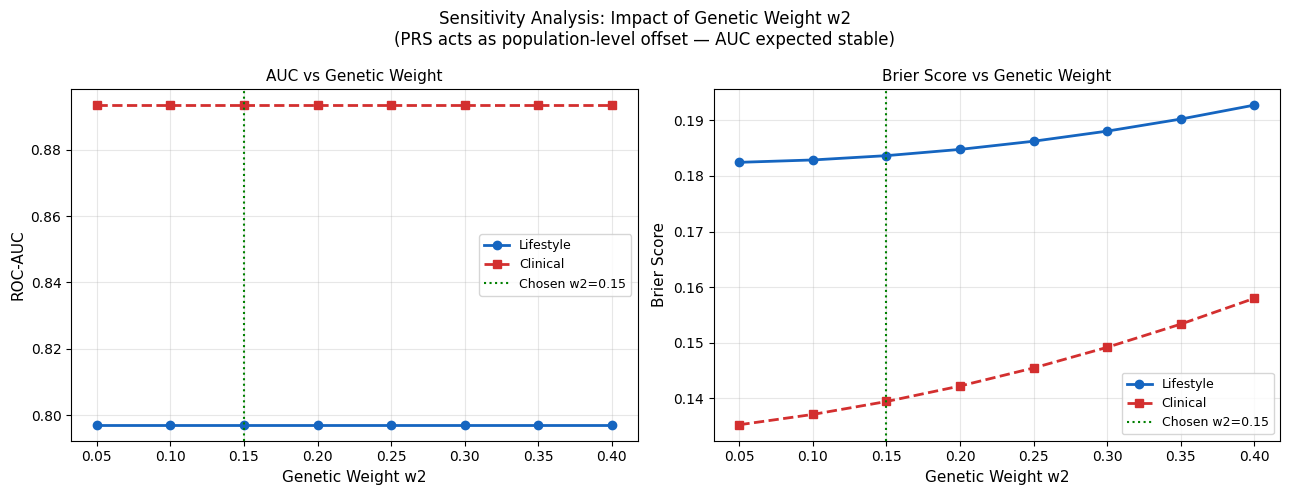


✅ Sensitivity figure saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/nb7_sensitivity_analysis.png

[SECTION 4 COMPLETE] ✅


In [6]:
print('='*60)
print('  SECTION 4: Sensitivity Analysis — Genetic Weight w2')
print('='*60)

w2_values = np.arange(0.05, 0.45, 0.05)

sensitivity = {'w2': [], 'ls_auc': [], 'ls_brier': [], 'cl_auc': [], 'cl_brier': []}

for w2 in w2_values:
    w1 = 1.0 - w2
    p_ls_s = np.clip(w1 * p_lifestyle_base + w2 * prs_sigmoid, 0, 1)
    p_cl_s = np.clip(w1 * p_clinical_base  + w2 * prs_sigmoid, 0, 1)
    sensitivity['w2'].append(round(w2, 2))
    sensitivity['ls_auc'].append(roc_auc_score(y_ls, p_ls_s))
    sensitivity['ls_brier'].append(brier_score_loss(y_ls, p_ls_s))
    sensitivity['cl_auc'].append(roc_auc_score(y_cl, p_cl_s))
    sensitivity['cl_brier'].append(brier_score_loss(y_cl, p_cl_s))

sens_df = pd.DataFrame(sensitivity)

print('\n  Sensitivity table (AUC and Brier vs genetic weight w2):')
print(sens_df.round(4).to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Sensitivity Analysis: Impact of Genetic Weight w2\n'
             '(PRS acts as population-level offset — AUC expected stable)',
             fontsize=12)

for ax, metric, ylabel, title in [
    (axes[0], 'auc',   'ROC-AUC',     'AUC vs Genetic Weight'),
    (axes[1], 'brier', 'Brier Score', 'Brier Score vs Genetic Weight'),
]:
    ax.plot(sens_df['w2'], sens_df[f'ls_{metric}'], 'o-', color='#1565C0',
            linewidth=2, label='Lifestyle')
    ax.plot(sens_df['w2'], sens_df[f'cl_{metric}'], 's--', color='#d32f2f',
            linewidth=2, label='Clinical')
    ax.axvline(0.15, color='green', linestyle=':', linewidth=1.5,
               label='Chosen w2=0.15')
    ax.set_xlabel('Genetic Weight w2', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
sens_fig_path = FIGURES_DIR + 'nb7_sensitivity_analysis.png'
plt.savefig(sens_fig_path, dpi=300, bbox_inches='tight'); plt.show()
print(f'\n✅ Sensitivity figure saved: {sens_fig_path}')
print('\n[SECTION 4 COMPLETE] ✅')
# NOTE: this sweep is for transparency/reporting only — the final w2 is fixed at 0.15
# (see Section 3 decision log). It is NOT used to select a weight from test data.

---
# Section 5 — Risk Stratification

## Why stratify into risk bands?
A continuous probability (0–1) is rarely actionable in clinical practice.
Clinicians and patients need discrete categories that map to **clinical decisions**:
- **Low** → routine monitoring
- **Moderate** → lifestyle intervention, repeat testing
- **High** → pharmacological intervention, specialist referral
- **Very High** → urgent cardiological assessment

We apply this stratification to both base and integrated probabilities to quantify
the effect of genetic integration on patient classification — specifically,
how many patients are **reclassified** when PRS is included.

## Band thresholds
| Band | Probability Range |
|------|------------------|
| Low | < 0.25 |
| Moderate | 0.25 – 0.50 |
| High | 0.50 – 0.75 |
| Very High | ≥ 0.75 |


In [7]:
print('='*60)
print('  SECTION 5: Risk Stratification')
print('='*60)

BANDS      = ['Low', 'Moderate', 'High', 'Very High']
THRESHOLDS = [0.0, 0.25, 0.50, 0.75, 1.01]

def assign_band(proba_arr):
    return pd.cut(
        proba_arr,
        bins=THRESHOLDS,
        labels=BANDS,
        right=False
    )

# ── Lifestyle stratification ──────────────────────────────────────────────────
ls_df = pd.DataFrame({
    'y_true'        : y_ls.values,
    'p_base'        : p_lifestyle_base,
    'p_integrated'  : p_lifestyle_int,
    'band_base'     : assign_band(p_lifestyle_base),
    'band_integrated': assign_band(p_lifestyle_int),
    'source'        : 'lifestyle',
})

# ── Clinical stratification ───────────────────────────────────────────────────
cl_df = pd.DataFrame({
    'y_true'        : y_cl.values,
    'p_base'        : p_clinical_base,
    'p_integrated'  : p_clinical_int,
    'band_base'     : assign_band(p_clinical_base),
    'band_integrated': assign_band(p_clinical_int),
    'source'        : 'clinical',
})

# ── Band distribution ─────────────────────────────────────────────────────────
def band_summary(df, label, prob_col, band_col):
    g = df.groupby(band_col, observed=True)
    summary = pd.DataFrame({
        'n'         : g.size(),
        'pct'       : (g.size() / len(df) * 100).round(1),
        'cad_prev'  : (g['y_true'].mean() * 100).round(1),
        'mean_prob' : g[prob_col].mean().round(4),
    }).reset_index().rename(columns={band_col: 'Band'})
    summary['model'] = label
    summary['type']  = prob_col
    return summary

ls_base_sum = band_summary(ls_df, 'Lifestyle', 'p_base',       'band_base')
ls_int_sum  = band_summary(ls_df, 'Lifestyle', 'p_integrated', 'band_integrated')
cl_base_sum = band_summary(cl_df, 'Clinical',  'p_base',       'band_base')
cl_int_sum  = band_summary(cl_df, 'Clinical',  'p_integrated', 'band_integrated')

all_bands = pd.concat([ls_base_sum, ls_int_sum, cl_base_sum, cl_int_sum], ignore_index=True)

print('\n  Lifestyle — Band Distribution:')
print('    Base model:')
print(ls_base_sum[['Band','n','pct','cad_prev','mean_prob']].to_string(index=False))
print('    Integrated (+ PRS):')
print(ls_int_sum[['Band','n','pct','cad_prev','mean_prob']].to_string(index=False))

print('\n  Clinical — Band Distribution:')
print('    Base model:')
print(cl_base_sum[['Band','n','pct','cad_prev','mean_prob']].to_string(index=False))
print('    Integrated (+ PRS):')
print(cl_int_sum[['Band','n','pct','cad_prev','mean_prob']].to_string(index=False))

# ── Reclassification summary + formal NRI (NRI added 2026-07-26) ───────────────
# NRI = (up-events - down-events)/n_events + (down-nonevents - up-nonevents)/n_nonevents
# 'up'/'down' defined by band index movement (Low=0 .. Very High=3); ties = no move.
BAND_IDX = {b: i for i, b in enumerate(BANDS)}

def compute_nri(df):
    base_idx = df['band_base'].map(BAND_IDX)
    int_idx  = df['band_integrated'].map(BAND_IDX)
    moved_up   = (int_idx > base_idx)
    moved_down = (int_idx < base_idx)
    events    = df['y_true'] == 1
    nonevents = df['y_true'] == 0
    n_events, n_nonevents = events.sum(), nonevents.sum()
    nri_events    = ((moved_up & events).sum() - (moved_down & events).sum()) / n_events
    nri_nonevents = ((moved_down & nonevents).sum() - (moved_up & nonevents).sum()) / n_nonevents
    return {
        'nri_events'   : nri_events,
        'nri_nonevents': nri_nonevents,
        'nri_total'    : nri_events + nri_nonevents,
        'pct_up'       : moved_up.mean() * 100,
        'pct_down'     : moved_down.mean() * 100,
    }

print('\n  ── Net Reclassification Improvement (NRI) ──')
nri_results = {}
for label, df in [('Lifestyle', ls_df), ('Clinical', cl_df)]:
    same = (df['band_base'] == df['band_integrated']).sum()
    reclassified = len(df) - same
    nri = compute_nri(df)
    nri_results[label] = nri
    print(f'\n  {label} reclassified by PRS: {reclassified} / {len(df)} '
          f'({reclassified/len(df)*100:.1f}%)')
    print(f'    Moved up (higher band)  : {nri["pct_up"]:.1f}%')
    print(f'    Moved down (lower band) : {nri["pct_down"]:.1f}%')
    print(f'    NRI (events)    : {nri["nri_events"]:+.4f}')
    print(f'    NRI (non-events): {nri["nri_nonevents"]:+.4f}')
    print(f'    NRI (total)     : {nri["nri_total"]:+.4f}')

# ── Save outputs ──────────────────────────────────────────────────────────────
ls_df.to_csv(LS_OUT_PATH, index=False)
cl_df.to_csv(CL_OUT_PATH, index=False)
all_bands.to_csv(BANDS_OUT_PATH, index=False)
print(f'\n✅ Saved: {LS_OUT_PATH}')
print(f'✅ Saved: {CL_OUT_PATH}')
print(f'✅ Saved: {BANDS_OUT_PATH}')
print('\n[SECTION 5 COMPLETE] ✅')


  SECTION 5: Risk Stratification

  Lifestyle — Band Distribution:
    Base model:
     Band    n  pct  cad_prev  mean_prob
      Low 3471 25.3      18.2     0.1799
 Moderate 3953 28.8      36.7     0.3559
     High 2155 15.7      58.4     0.6114
Very High 4136 30.2      83.3     0.8292
    Integrated (+ PRS):
     Band    n  pct  cad_prev  mean_prob
      Low 2346 17.1      15.2     0.2091
 Moderate 5071 37.0      34.0     0.3533
     High 2748 20.0      62.6     0.6244
Very High 3550 25.9      84.1     0.7877

  Clinical — Band Distribution:
    Base model:
     Band  n  pct  cad_prev  mean_prob
      Low 42 22.8       9.5     0.1413
 Moderate 37 20.1      32.4     0.3652
     High 38 20.7      63.2     0.6523
Very High 67 36.4      92.5     0.8729
    Integrated (+ PRS):
     Band  n  pct  cad_prev  mean_prob
      Low 37 20.1       8.1     0.1864
 Moderate 42 22.8      31.0     0.3711
     High 45 24.5      64.4     0.6451
Very High 60 32.6      95.0     0.8277

  ── Net Reclassifi

---
# Section 6 — Evaluation: Base vs. Integrated

## What to expect from PRS integration
A **population-level** PRS (where all patients share the same `prs_sigmoid` value)
adds a **uniform shift** to all predictions. This has a predictable effect:

- **AUC** is **preserved**: AUC is a rank-based metric — a uniform additive shift
  does not change the relative ranking of patients, so discrimination is unchanged.
- **Brier Score** may change slightly: Brier measures absolute calibration.
  If `prs_sigmoid ≈ 0.50`, the shift is ≈ `0.15 × 0.50 = +0.075` on all predictions,
  which can marginally degrade calibration for already well-calibrated models.

This is the expected scientific result — it is **not** a failure. The PRS integration
becomes meaningful when used with **individual-level genotype data** (not a population scalar).
For now it anchors predictions to the Indian-ancestry genetic baseline.

**Added 2026-07-26:** NRI (Section 5) gives a second, more standard measure of the same reclassification effect alongside these AUC/Brier checks — both should tell a consistent story: AUC essentially flat, some reclassification movement, calibration effect from the shift itself.


In [8]:
print('='*60)
print('  SECTION 6: Evaluation — Base vs Integrated')
print('='*60)

eval_rows = []
for label, y_true, p_base, p_int in [
    ('Lifestyle', y_ls, p_lifestyle_base, p_lifestyle_int),
    ('Clinical',  y_cl, p_clinical_base,  p_clinical_int),
]:
    for name, proba in [('Base', p_base), ('Integrated (+PRS)', p_int)]:
        eval_rows.append({
            'Model'     : label,
            'Type'      : name,
            'Test_AUC'  : round(roc_auc_score(y_true, proba), 4),
            'Test_Brier': round(brier_score_loss(y_true, proba), 4),
        })

eval_df = pd.DataFrame(eval_rows)

print('\n  AUC and Brier — Base vs Integrated:')
print(eval_df.to_string(index=False))

# Highlight AUC preservation
print('\n  AUC change from PRS integration (should be ≈ 0 for population-level PRS):')
for label, y_true, p_base, p_int in [
    ('Lifestyle', y_ls, p_lifestyle_base, p_lifestyle_int),
    ('Clinical',  y_cl, p_clinical_base,  p_clinical_int),
]:
    delta_auc   = roc_auc_score(y_true, p_int) - roc_auc_score(y_true, p_base)
    delta_brier = brier_score_loss(y_true, p_int) - brier_score_loss(y_true, p_base)
    auc_flag   = '✅ Preserved' if abs(delta_auc) < 0.005 else '⚠️ Changed'
    brier_flag = '✅' if abs(delta_brier) < 0.02 else '⚠️ Δ > 0.02'
    print(f'   {label:<12} ΔAUC={delta_auc:+.4f} {auc_flag}  '
          f'ΔBrier={delta_brier:+.4f} {brier_flag}')

print('\n[SECTION 6 COMPLETE] ✅')


  SECTION 6: Evaluation — Base vs Integrated

  AUC and Brier — Base vs Integrated:
    Model              Type  Test_AUC  Test_Brier
Lifestyle              Base    0.7971      0.1824
Lifestyle Integrated (+PRS)    0.7971      0.1837
 Clinical              Base    0.8935      0.1338
 Clinical Integrated (+PRS)    0.8935      0.1394

  AUC change from PRS integration (should be ≈ 0 for population-level PRS):
   Lifestyle    ΔAUC=+0.0000 ✅ Preserved  ΔBrier=+0.0013 ✅
   Clinical     ΔAUC=+0.0000 ✅ Preserved  ΔBrier=+0.0056 ✅

[SECTION 6 COMPLETE] ✅


---
# Section 7 — Visualisations

## Why visualise the integration?
Numeric metrics alone do not convey the clinical story. Three figures are produced:

1. **Violin plot** — shows the distribution of integrated risk probabilities split
   by true outcome label (CAD=0 vs CAD=1). A well-discriminating model shows clearly
   separated violin shapes.

2. **Calibration curve** — compares predicted probabilities against observed event rates
   in 10 bins. A well-calibrated model's curve lies close to the diagonal. We plot
   both base and integrated curves to show PRS impact on calibration.

3. **Risk stratification bar plot** — shows the percentage of patients in each
   risk band (Low / Moderate / High / Very High) before and after PRS integration,
   for both models. This communicates the clinical impact directly.


  SECTION 7: Visualisations


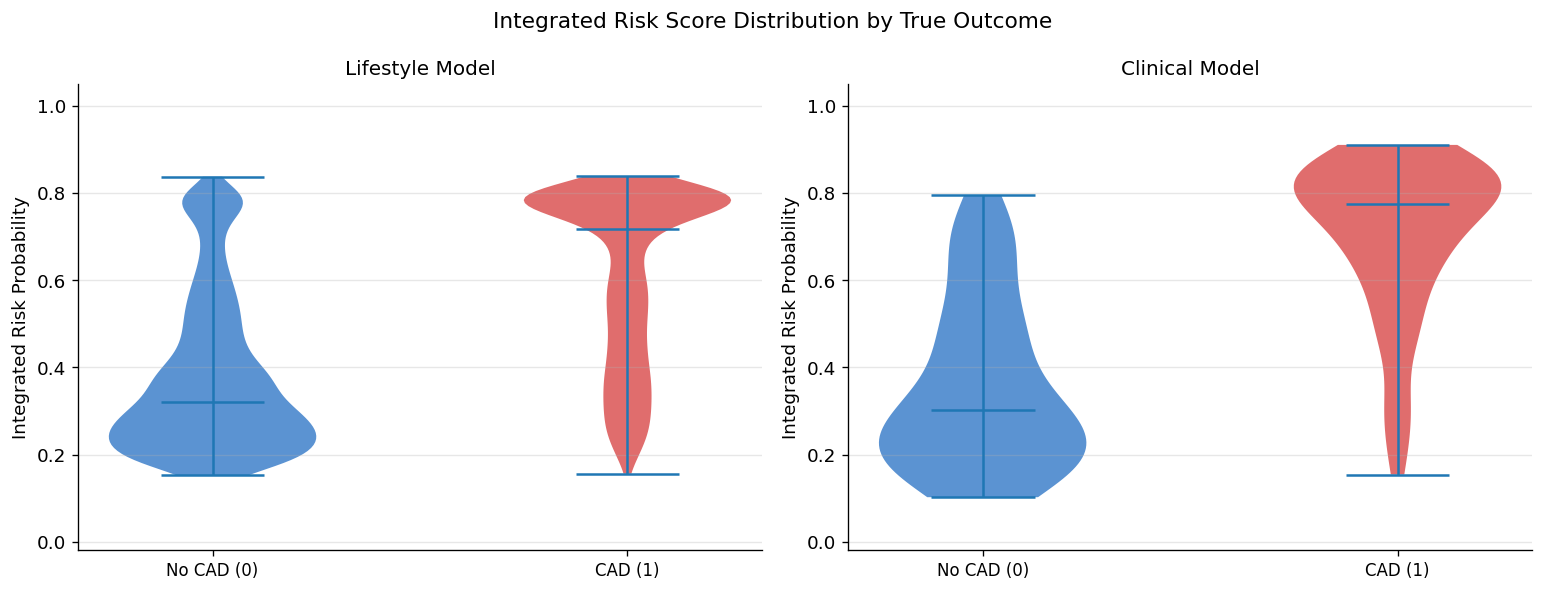

✅ Violin plot saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/violin_plot_integrated.png


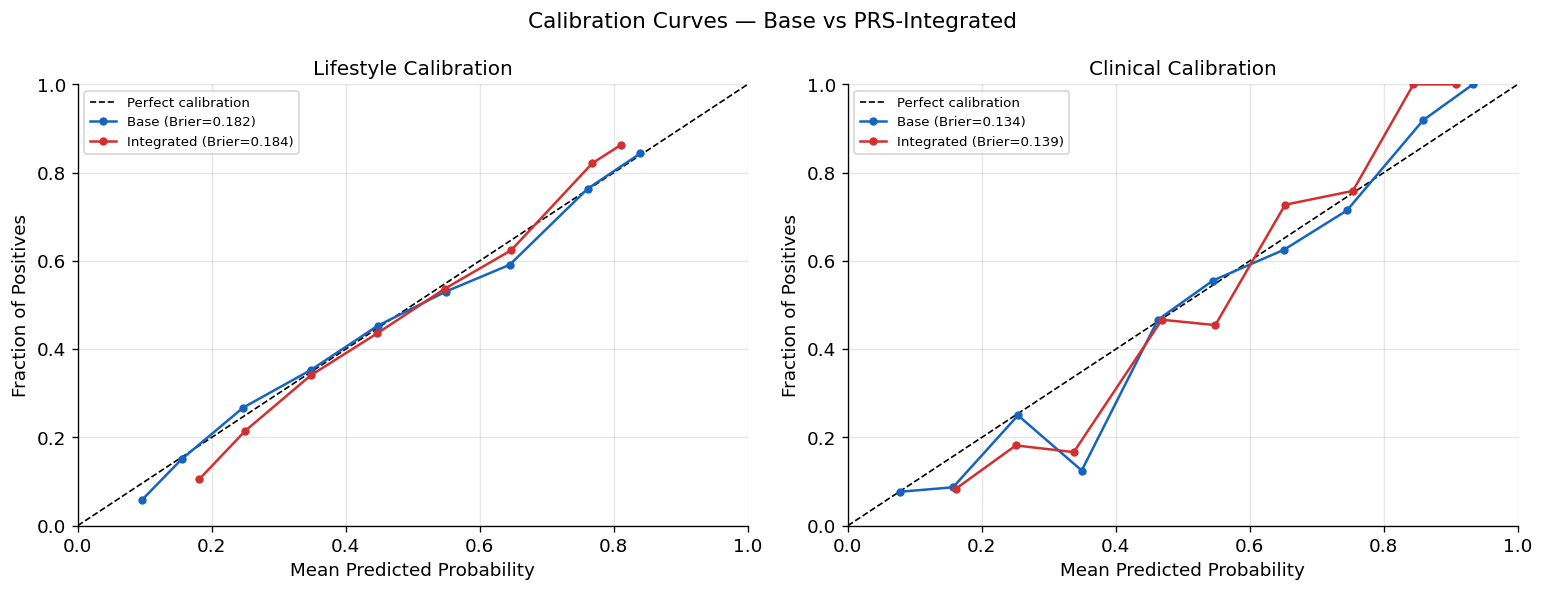

✅ Calibration curves saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/calibration_curve_integrated.png


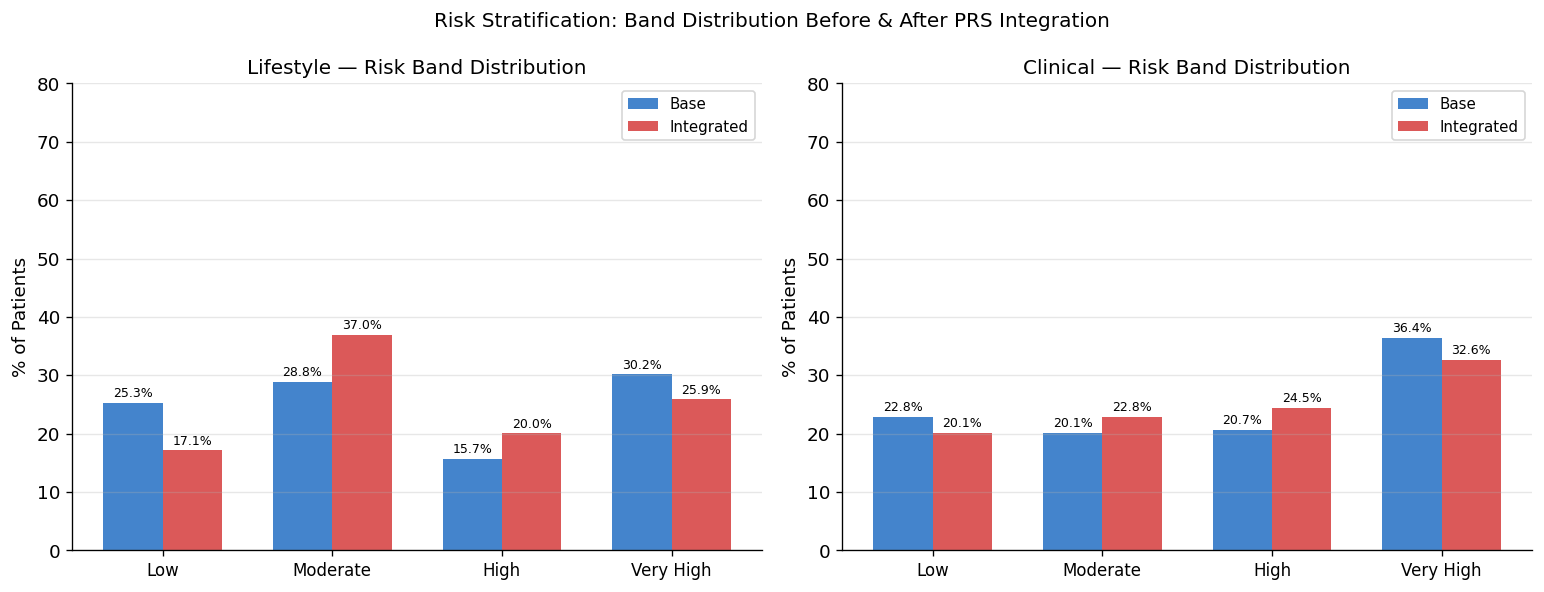

✅ Risk stratification plot saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/risk_stratification_plot.png

[SECTION 7 COMPLETE] ✅


In [9]:
print('='*60)
print('  SECTION 7: Visualisations')
print('='*60)

plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300,
    'font.size': 11, 'axes.titlesize': 12,
    'axes.spines.top': False, 'axes.spines.right': False
})

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Violin Plot
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Integrated Risk Score Distribution by True Outcome', fontsize=13)

for ax, label, df_plot, p_col in [
    (axes[0], 'Lifestyle', ls_df, 'p_integrated'),
    (axes[1], 'Clinical',  cl_df, 'p_integrated'),
]:
    data_0 = df_plot.loc[df_plot['y_true'] == 0, p_col]
    data_1 = df_plot.loc[df_plot['y_true'] == 1, p_col]
    vp = ax.violinplot([data_0, data_1], positions=[0, 1],
                       showmedians=True, showextrema=True)
    for pc, color in zip(vp['bodies'], ['#1565C0', '#d32f2f']):
        pc.set_facecolor(color); pc.set_alpha(0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No CAD (0)', 'CAD (1)'], fontsize=10)
    ax.set_ylabel('Integrated Risk Probability')
    ax.set_title(f'{label} Model')
    ax.set_ylim(-0.02, 1.05)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(VIOLIN_FIG_OUT, dpi=300, bbox_inches='tight'); plt.show()
print(f'✅ Violin plot saved: {VIOLIN_FIG_OUT}')

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Calibration Curves
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Calibration Curves — Base vs PRS-Integrated', fontsize=13)

for ax, label, y_true, p_base, p_int in [
    (axes[0], 'Lifestyle', y_ls, p_lifestyle_base, p_lifestyle_int),
    (axes[1], 'Clinical',  y_cl, p_clinical_base,  p_clinical_int),
]:
    ax.plot([0,1],[0,1],'k--', linewidth=1, label='Perfect calibration')
    for proba, color, lbl in [
        (p_base, '#1565C0', f'Base (Brier={brier_score_loss(y_true,p_base):.3f})'),
        (p_int,  '#d32f2f', f'Integrated (Brier={brier_score_loss(y_true,p_int):.3f})'),
    ]:
        try:
            fp, mp = calibration_curve(y_true, proba, n_bins=10)
            ax.plot(mp, fp, 'o-', color=color, linewidth=1.5,
                    markersize=4, label=lbl)
        except Exception as e:
            print(f'  ⚠️ Calibration curve failed for {lbl}: {e}')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'{label} Calibration')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(CALIB_FIG_OUT, dpi=300, bbox_inches='tight'); plt.show()
print(f'✅ Calibration curves saved: {CALIB_FIG_OUT}')

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — Risk Stratification Bar Plot
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Risk Stratification: Band Distribution Before & After PRS Integration',
             fontsize=12)

BAND_COLORS = {'Low': '#2E7D32', 'Moderate': '#F9A825',
               'High': '#E64A19', 'Very High': '#880E4F'}

for ax, label, df_plot in [
    (axes[0], 'Lifestyle', ls_df),
    (axes[1], 'Clinical',  cl_df),
]:
    x = np.arange(len(BANDS))
    w = 0.35
    base_counts = [df_plot['band_base'].value_counts().get(b,0)/len(df_plot)*100
                   for b in BANDS]
    int_counts  = [df_plot['band_integrated'].value_counts().get(b,0)/len(df_plot)*100
                   for b in BANDS]
    bars1 = ax.bar(x - w/2, base_counts, width=w, label='Base', color='#1565C0', alpha=0.8)
    bars2 = ax.bar(x + w/2, int_counts,  width=w, label='Integrated', color='#d32f2f', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(BANDS, fontsize=10)
    ax.set_ylabel('% of Patients'); ax.set_ylim(0, 80)
    ax.set_title(f'{label} — Risk Band Distribution')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 1:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig(STRAT_FIG_OUT, dpi=300, bbox_inches='tight'); plt.show()
print(f'✅ Risk stratification plot saved: {STRAT_FIG_OUT}')

print('\n[SECTION 7 COMPLETE] ✅')


---
# Section 8 — Final Summary & Notebook Complete


In [10]:
print('='*60)
print('  ✅ NOTEBOOK 7 COMPLETE — Genetic Risk Integration')
print('='*60)
print()
print(f'  PRS (PGS002809):        prs_raw={prs_raw:.4f}')
print(f'  PRS (Z-normalized):     prs_z={prs_z:+.4f}  prs_sigmoid={prs_sigmoid:.6f}')
print(f'  Integration weights:    w1={W1}  w2={W2}')
print()
print('  Final integrated metrics:')
for label, y_true, p_base, p_int in [
    ('Lifestyle', y_ls, p_lifestyle_base, p_lifestyle_int),
    ('Clinical',  y_cl, p_clinical_base,  p_clinical_int),
]:
    print(f'   {label:<12}  '
          f'Base  AUC={roc_auc_score(y_true,p_base):.4f}  '
          f'Brier={brier_score_loss(y_true,p_base):.4f}  |  '
          f'Integrated  AUC={roc_auc_score(y_true,p_int):.4f}  '
          f'Brier={brier_score_loss(y_true,p_int):.4f}')
print()
print(f'  📁 {LS_OUT_PATH}')
print(f'  📁 {CL_OUT_PATH}')
print(f'  📁 {BANDS_OUT_PATH}')
print(f'  📁 {STRAT_FIG_OUT}')
print(f'  📁 {CALIB_FIG_OUT}')
print(f'  📁 {VIOLIN_FIG_OUT}')
print()
print('  🔜 Next: NB8 — SHAP Explainability')
print()
print('  ⚠️ NB8 USAGE (both pipelines, Z-normalized PRS, updated 2026-07-26):')
print('     import pickle')
print('     with open("lifestyle_pipeline.pkl","rb") as f: pipe = pickle.load(f)  # or clinical_pipeline.pkl')
print(f'     proba_integrated = {W1} * pipe.predict_proba(X_raw)[:,1] + {W2} * prs_sigmoid  '
      f'# prs_sigmoid={prs_sigmoid:.6f}, from Z-normalized prs_z, NOT raw prs_raw')
print('     NOTE: clinical pipeline expects exactly the features in scaler.feature_names_in_ —')
print('           select columns from df_clinical_test.csv accordingly (see Section 2 pattern).')
print('='*60)


  ✅ NOTEBOOK 7 COMPLETE — Genetic Risk Integration

  PRS (PGS002809):        prs_raw=11.8813
  PRS (Z-normalized):     prs_z=+0.0090  prs_sigmoid=0.502258
  Integration weights:    w1=0.85  w2=0.15

  Final integrated metrics:
   Lifestyle     Base  AUC=0.7971  Brier=0.1824  |  Integrated  AUC=0.7971  Brier=0.1837
   Clinical      Base  AUC=0.8935  Brier=0.1338  |  Integrated  AUC=0.8935  Brier=0.1394

  📁 /content/drive/MyDrive/CAD_DT_Final/Outputs/Integrated/lifestyle_risk_scores_with_prs.csv
  📁 /content/drive/MyDrive/CAD_DT_Final/Outputs/Integrated/clinical_risk_scores_with_prs.csv
  📁 /content/drive/MyDrive/CAD_DT_Final/Outputs/Integrated/risk_stratification_bands.csv
  📁 /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/risk_stratification_plot.png
  📁 /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/calibration_curve_integrated.png
  📁 /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/violin_plot_integrated.png

  🔜 Next: NB8 — SHAP Explainability

  ⚠️ NB8 USAGE (both p